In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [5]:
df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/gev_fit_scores_kmeans_gev_k7.csv")
select_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_independce/independent_stations.csv")

In [8]:
select_df.drop(columns="station")

,Unnamed: 0,idx,lat,lon,decorrelation_days,error
0,0,0,48.383000,-4.495000,9.833333,NaN
1,2,2,50.102000,-5.542000,9.791667,NaN
2,4,4,50.099998,-5.533330,16.666667,NaN
3,5,5,50.608500,-2.447944,9.291667,NaN
4,7,7,46.497358,-1.793528,12.375000,NaN
...,...,...,...,...,...,...
250,289,289,49.930000,1.085000,9.250000,NaN
251,290,290,49.481602,0.105600,6.333333,NaN
252,291,291,49.651299,-1.635500,7.750000,NaN
253,293,293,49.183300,-2.116700,8.750000,NaN


In [4]:
df

,station,lat,lon,n_blocks,gev_c,gev_loc,gev_scale,ks_stat,ks_pvalue,kuiper,r2_cdf,cluster
0,1,48.383000,-4.495000,399,0.019241,0.396674,0.154282,0.024866,9.608442e-01,0.049478,0.998840,3
1,10,45.568480,-1.061555,237,0.008878,0.396981,0.213112,0.039548,8.378220e-01,0.076243,0.996154,3
2,102,50.102000,-5.542000,377,0.091471,0.382442,0.133961,0.028606,9.083926e-01,0.053212,0.998736,3
3,103,50.103000,-5.542750,448,0.182677,0.416630,0.338177,0.198556,5.918326e-16,0.348877,0.833575,1
4,104,50.099998,-5.533330,208,0.207224,0.355725,0.397805,0.227405,6.182796e-10,0.426216,0.779609,1
...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,49.930000,1.085000,354,0.134216,0.648701,0.249004,0.032953,8.243307e-01,0.060343,0.997794,1
275,94,49.481602,0.105600,334,-0.070928,0.606404,0.217717,0.049944,3.633716e-01,0.082440,0.994576,1
276,95,49.651299,-1.635500,307,0.041588,0.421740,0.156375,0.046920,4.939544e-01,0.092866,0.994406,3
277,97,49.183300,-2.116700,194,0.001428,0.500914,0.167152,0.047478,7.559014e-01,0.083292,0.995879,3


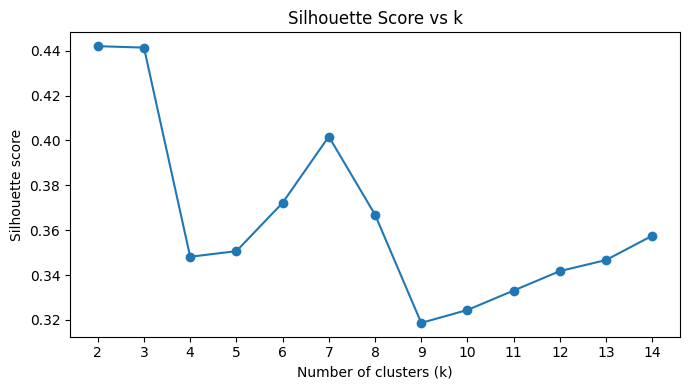

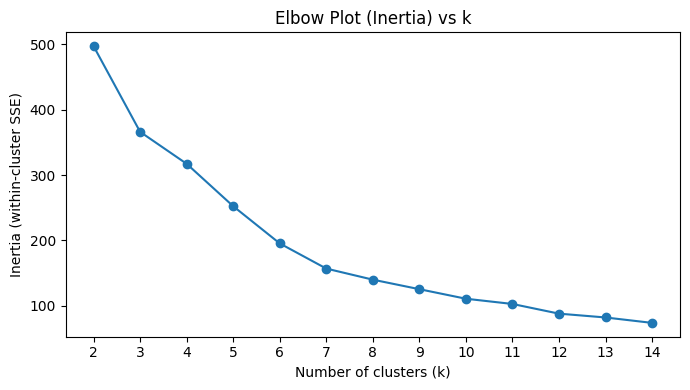

Best k by silhouette: 2
k= 2  silhouette=0.4420  inertia=497.36
k= 3  silhouette=0.4414  inertia=366.20
k= 4  silhouette=0.3482  inertia=317.27
k= 5  silhouette=0.3507  inertia=252.38
k= 6  silhouette=0.3722  inertia=195.40
k= 7  silhouette=0.4017  inertia=156.89
k= 8  silhouette=0.3669  inertia=139.93
k= 9  silhouette=0.3187  inertia=125.34
k=10  silhouette=0.3244  inertia=110.73
k=11  silhouette=0.3331  inertia=102.72
k=12  silhouette=0.3418  inertia=87.90
k=13  silhouette=0.3467  inertia=82.05
k=14  silhouette=0.3575  inertia=73.76


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# --- after df is created (and non-empty) ---

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

k_range = range(2, 15)  # adjust upper bound if you want
sil_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = km.fit_predict(Xs)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, labels))

# -----------------------------
# 1) Silhouette score plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Elbow plot (inertia)
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot (Inertia) vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: choose best k by silhouette
# -----------------------------
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k_sil)

# Optional: print table for logging
for k, s, iner in zip(k_range, sil_scores, inertias):
    print(f"k={k:2d}  silhouette={s:.4f}  inertia={iner:.2f}")


In [11]:
# 6) Fit final KMeans
best_k = 7
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)

Saved clustered GEV parameters to: gev_fit_scores_kmeans_gev_k7.csv


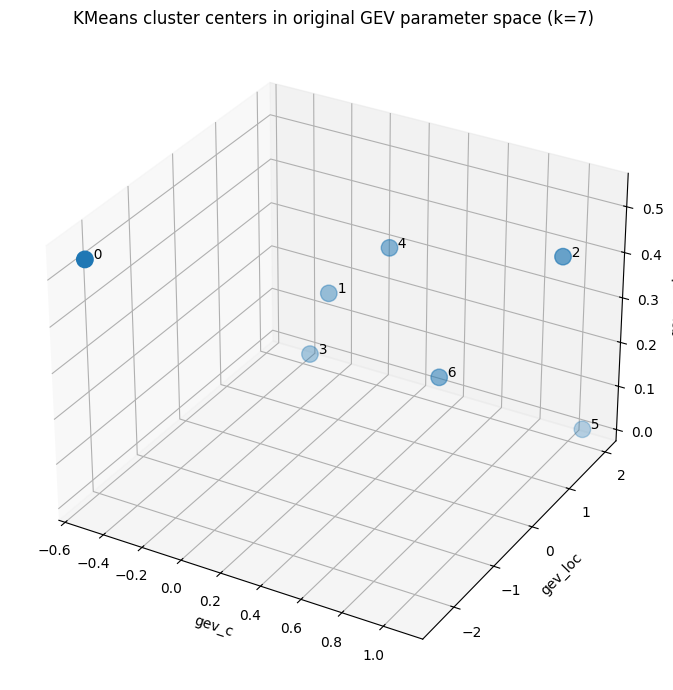

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Feature names (same order as used for fitting)
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

# --------------------------------------------------
# 1. Get cluster centers in standardized space
# --------------------------------------------------
centers_std = km.cluster_centers_  # shape (k, 3)

# --------------------------------------------------
# 2. Invert standardization
# --------------------------------------------------
centers_unscaled = scaler.inverse_transform(centers_std)

# --------------------------------------------------
# 3. Undo log-transform on gev_scale
# --------------------------------------------------
centers_unscaled = centers_unscaled.copy()
centers_unscaled[:, 2] = np.exp(centers_unscaled[:, 2])

# --------------------------------------------------
# 4. Plot in ORIGINAL PARAMETER SPACE
# --------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    centers_unscaled[:, 2],
    s=140,
    marker="o",
    depthshade=True,
)

# Label each cluster center
for i in range(centers_unscaled.shape[0]):
    ax.text(
        centers_unscaled[i, 0],
        centers_unscaled[i, 1],
        centers_unscaled[i, 2],
        f"  {i}",
        fontsize=10,
    )

ax.set_xlabel("gev_c")
ax.set_ylabel("gev_loc")
ax.set_zlabel("gev_scale")
ax.set_title(f"KMeans cluster centers in original GEV parameter space (k={best_k})")

plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_60791/3382529528.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)


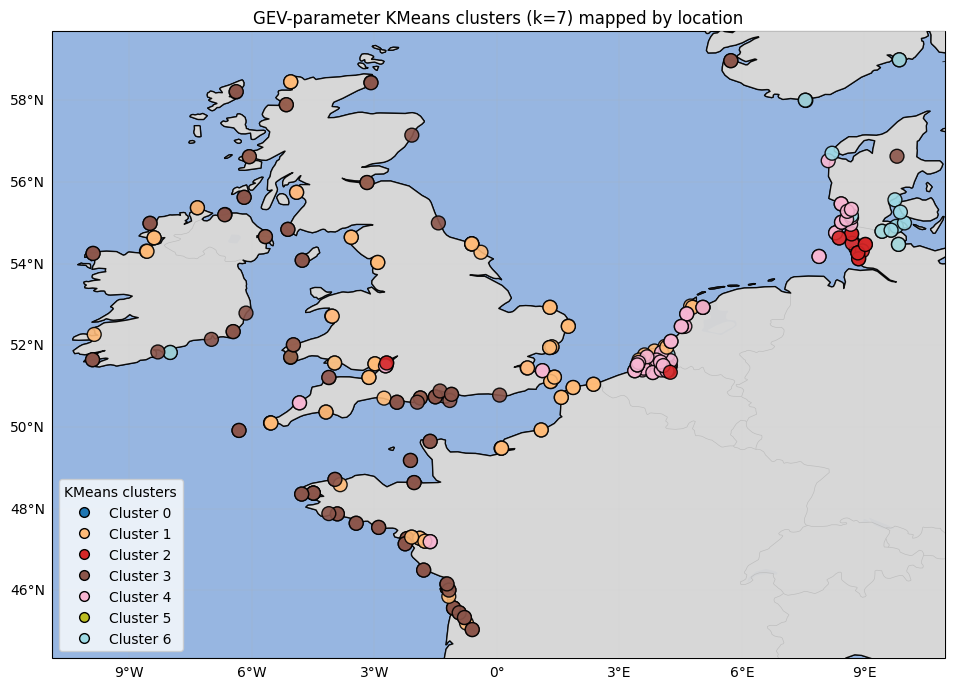

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(dfc.columns)

# Ensure numeric lon/lat and drop missing
plotdf = dfc[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)



# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


In [26]:
dfc.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")